# Machine Learning Assignment 2 - Semi-Supervised Learning for Predicting Survival Time in Multiple Myeloma Patients
***
## Group Members
- Geri Aliaj - 75360
- Ben Moritz Castello - 75197
- Maria Teresa Viciosa - 75149

## Task 1 Setting the baseline

As in the previous assignment, the first step is to set a baseline. The ML task is regression, and we will fit a linear regression model as a baseline, which we can use to compare with further developments.

### Task 1.1 Data preparation and validation pipeline


In [159]:
# Importing the necessary libraries

import pandas as pd
import missingno as msno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, FunctionTransformer
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
import time
import random

In [131]:
train_csv = pd.read_csv('train_data.csv')
train_csv.head(150)

,Unnamed: 0,Age,Gender,Stage,GeneticRisk,TreatmentType,ComorbidityIndex,TreatmentResponse,SurvivalTime,Censored
0,0,65.0,0,2,1.0,0,0.0,0.0,4.2,0
1,1,68.0,1,2,0.0,1,1.0,1.0,4.7,1
2,2,68.0,1,3,1.0,1,0.0,1.0,3.5,1
3,3,81.0,1,4,1.0,1,3.0,0.0,2.3,0
4,4,59.0,1,2,1.0,0,NaN,0.0,NaN,0
...,...,...,...,...,...,...,...,...,...,...
145,145,45.0,0,2,0.0,0,NaN,1.0,2.0,0
146,146,81.0,1,4,NaN,0,2.0,0.0,NaN,0
147,147,66.0,1,4,0.0,0,1.0,1.0,NaN,0
148,148,73.0,1,3,0.0,0,2.0,1.0,NaN,0


In [132]:
train_csv.describe()

,Unnamed: 0,Age,Gender,Stage,GeneticRisk,TreatmentType,ComorbidityIndex,TreatmentResponse,SurvivalTime,Censored
count,400.000000,400.00000,400.000000,400.000000,315.000000,400.000000,355.000000,371.000000,240.000000,400.000000
mean,199.500000,65.14250,0.590000,2.565000,0.285714,0.412500,1.092958,0.514825,4.479583,0.197500
std,115.614301,9.55434,0.492449,1.081063,0.452473,0.492901,0.869983,0.500455,2.015370,0.398611
min,0.000000,40.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000
25%,99.750000,59.00000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
50%,199.500000,65.00000,1.000000,2.500000,0.000000,0.000000,1.000000,1.000000,4.100000,0.000000
75%,299.250000,72.00000,1.000000,4.000000,1.000000,1.000000,2.000000,1.000000,5.700000,0.000000
max,399.000000,90.00000,1.000000,4.000000,1.000000,1.000000,3.000000,1.000000,12.100000,1.000000


<Axes: >

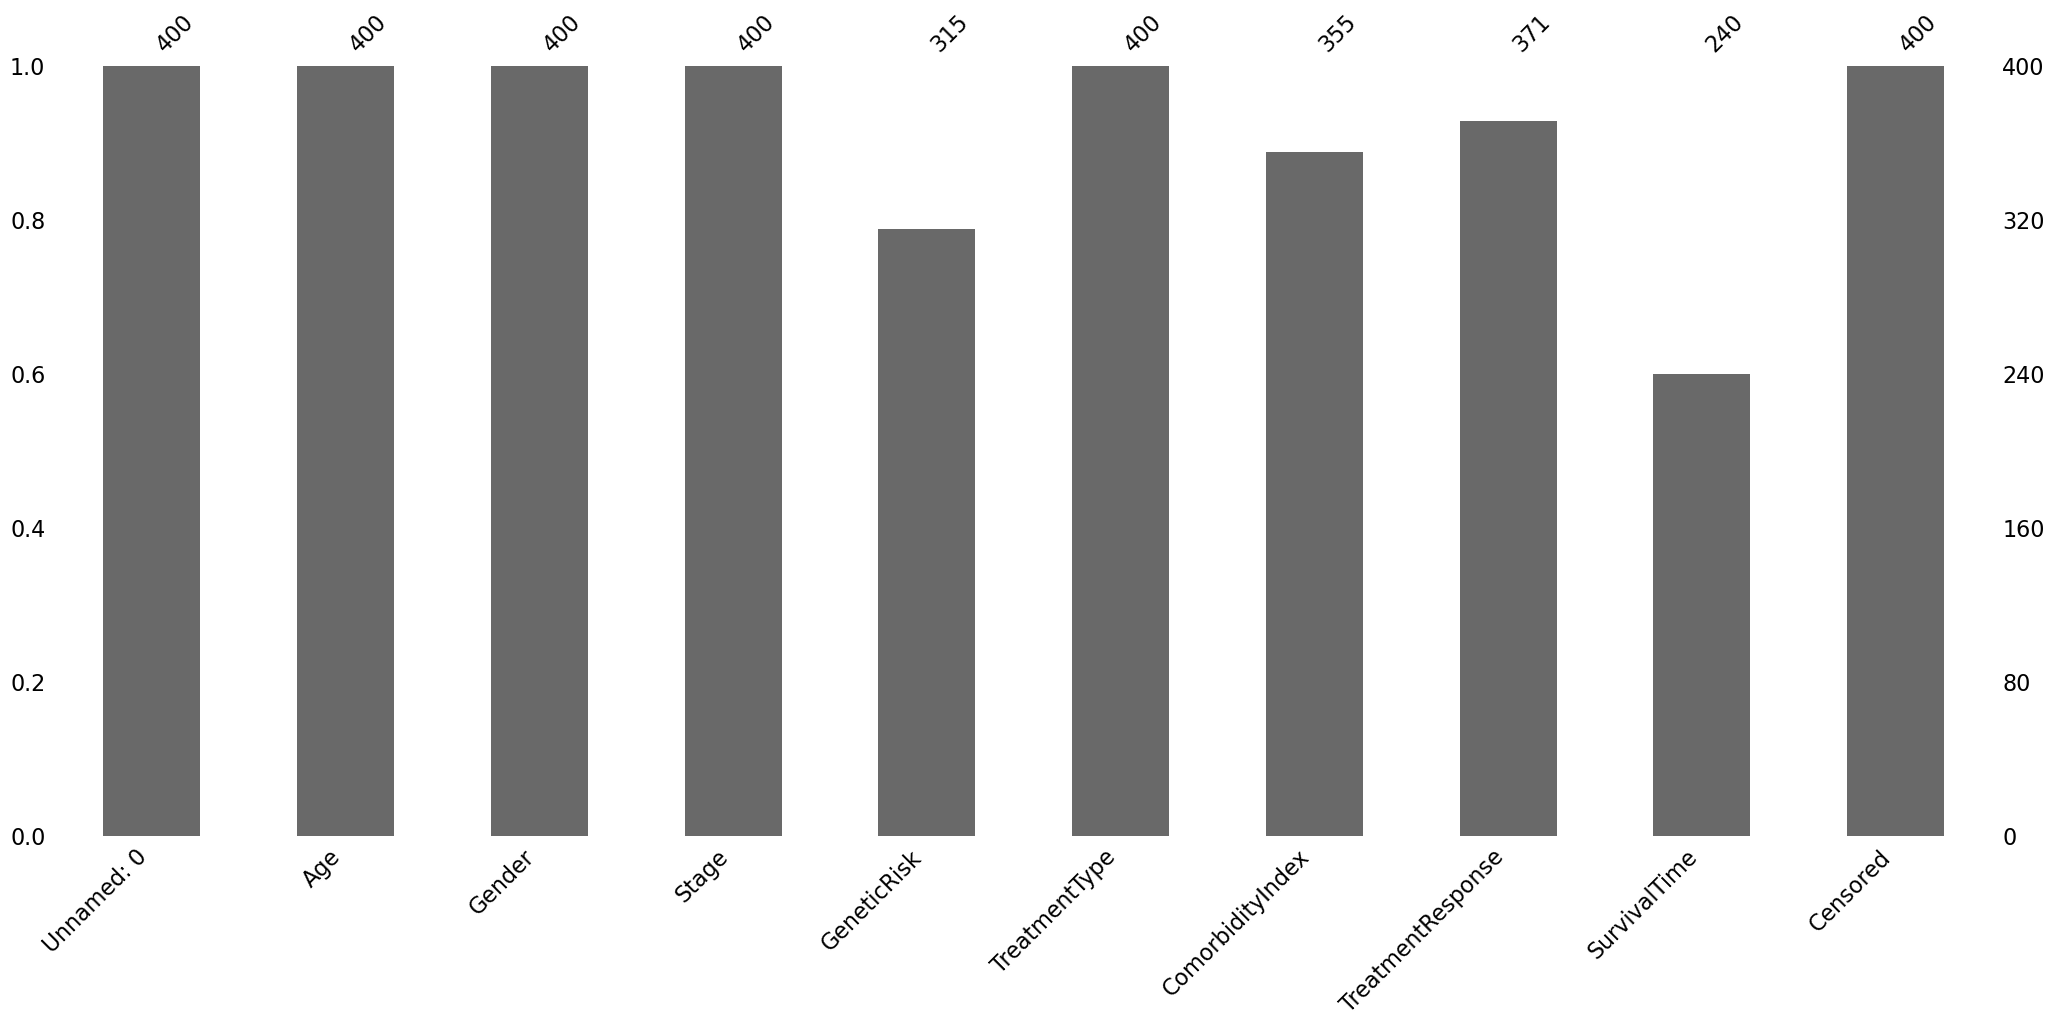

In [133]:
msno.bar(train_csv)

### How many cases are in the dataset?

In [135]:
# How many cases does our dataset have?
#num_rows = train_csv["id"].nunique()
#print(f"Total Number of cases: {num_rows}")

### Visualisation

<Axes: >

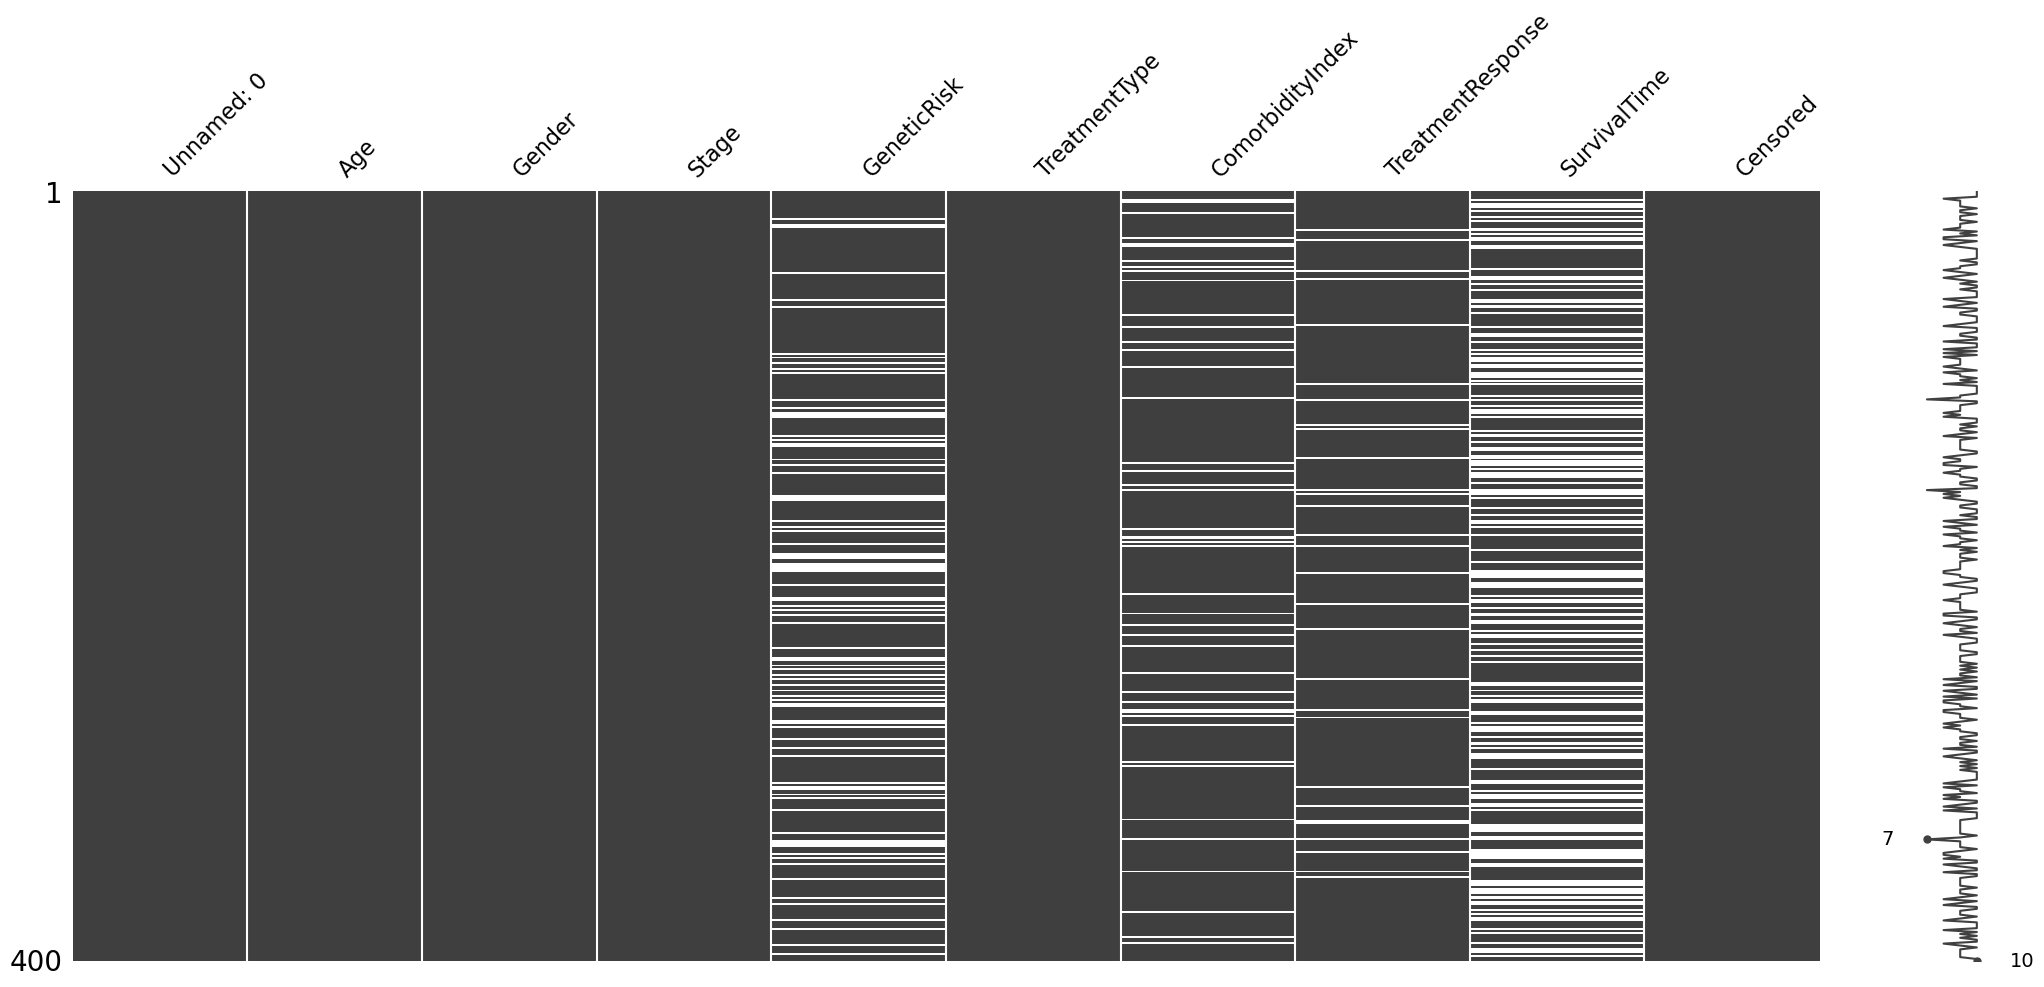

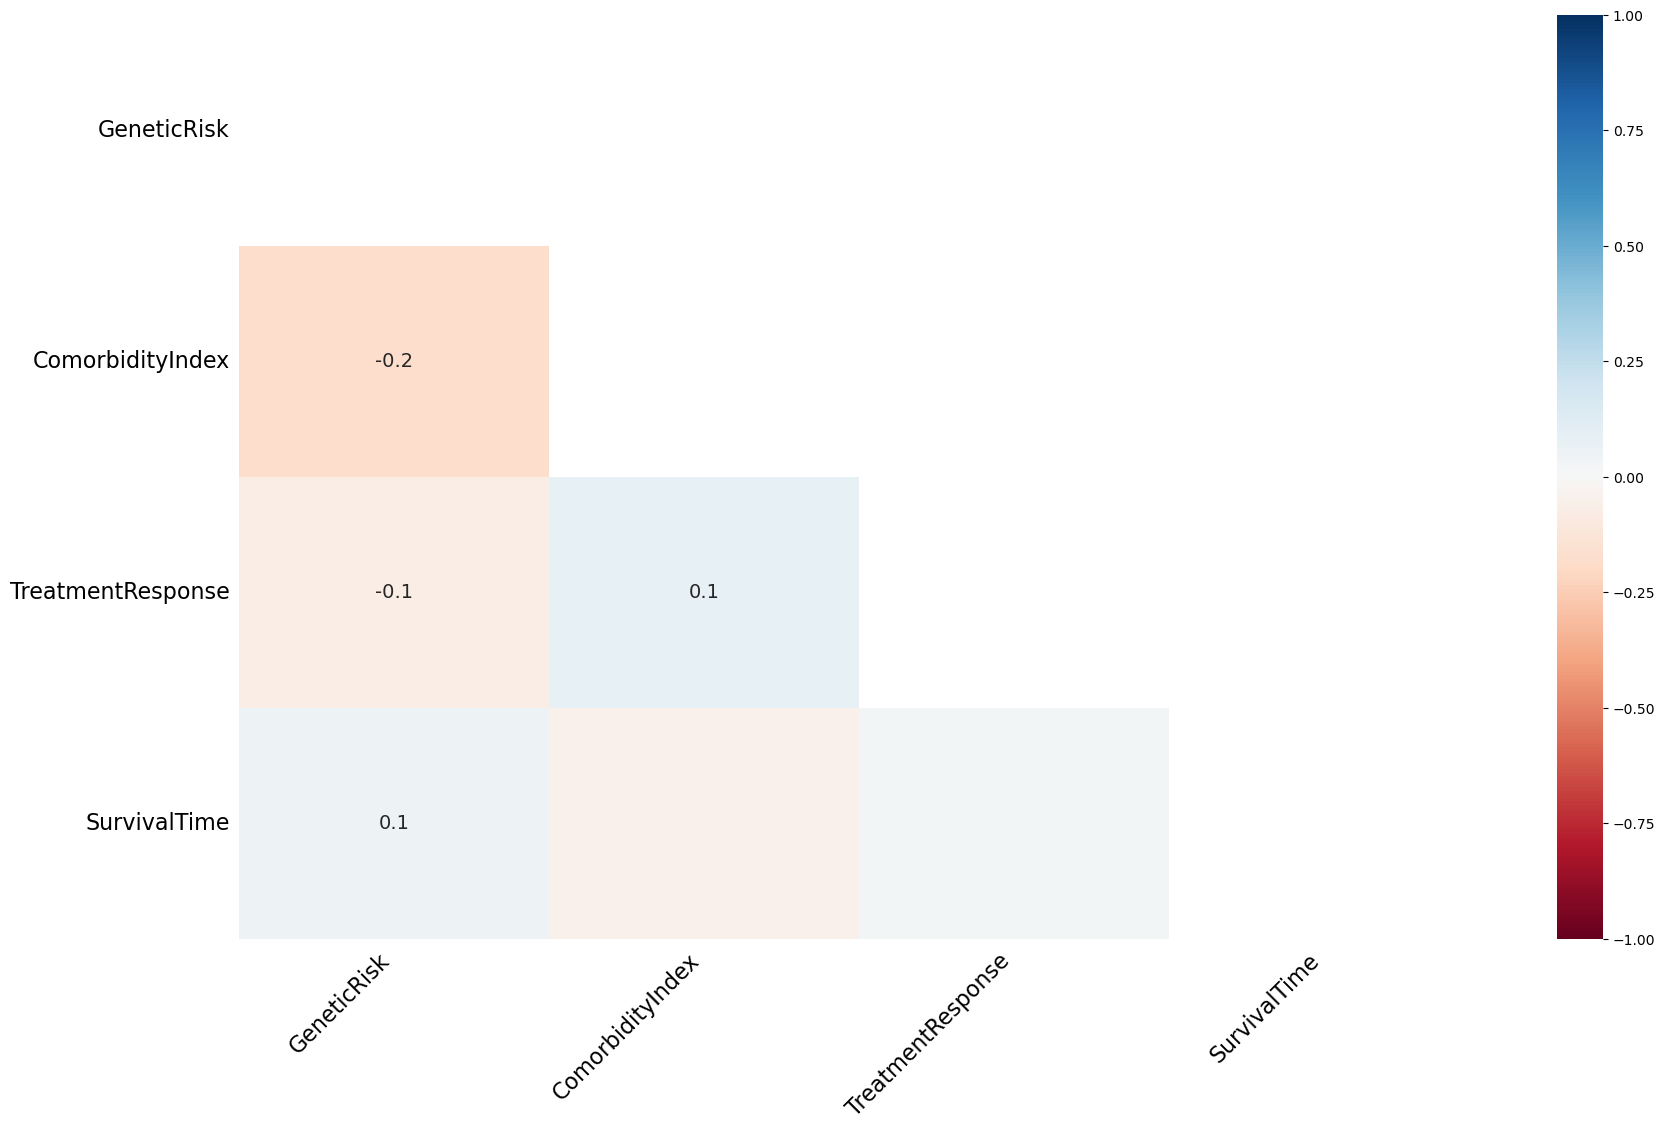

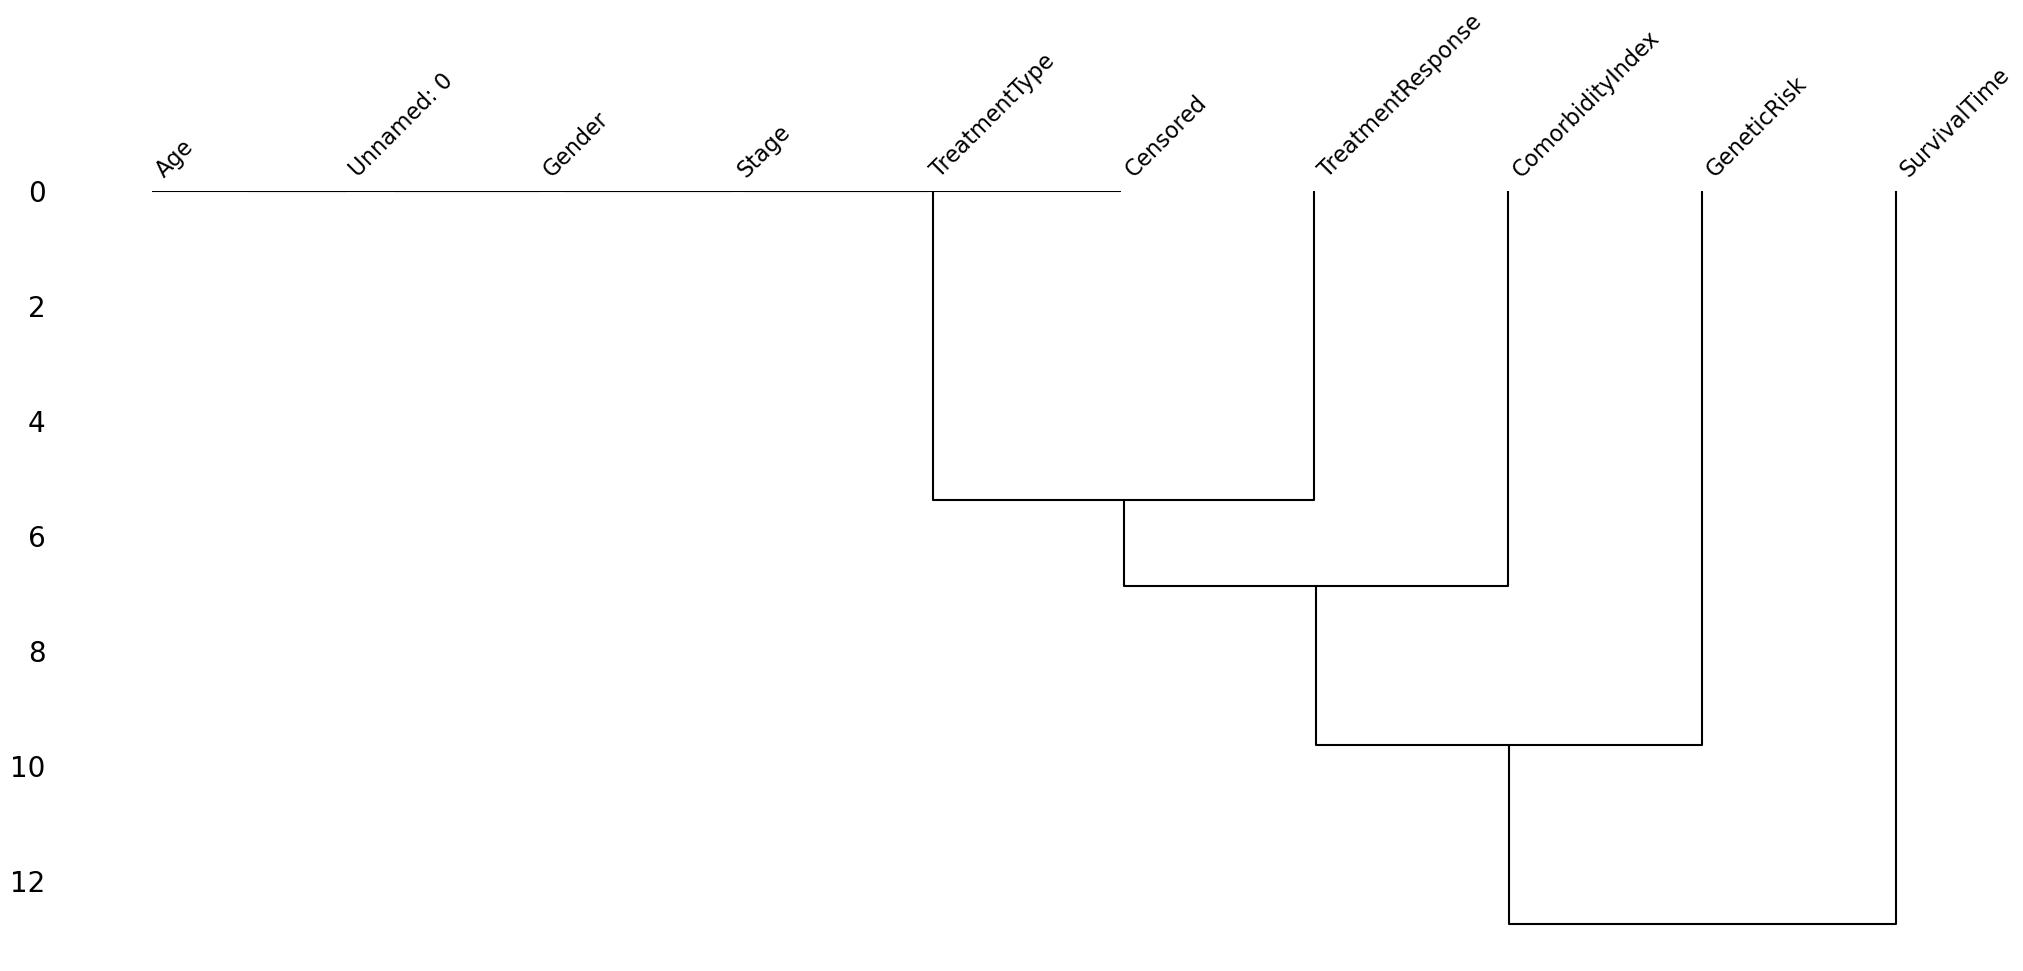

In [139]:
msno.matrix(train_csv)
msno.heatmap(train_csv)
msno.dendrogram(train_csv)

### Counting the Missing Values of each column

In [142]:
train_csv.isna().sum()

Unnamed: 0             0
Age                    0
Gender                 0
Stage                  0
GeneticRisk           85
TreatmentType          0
ComorbidityIndex      45
TreatmentResponse     29
SurvivalTime         160
Censored               0
dtype: int64

### How many rows are there without any Missing Values?

In [144]:
#train_wo_nan = train_csv.dropna() # I wrote w/o as without
#num_rows = train_wo_nan["id"].nunique()
#print(f"Total Number of cases: {num_rows}")

In [148]:
# Identify columns with missing values, but exclude 'SurvivalTime' and 'Censored'
cols_with_missing = [col for col in train_csv.columns if train_csv[col].isna().any() 
                     and col not in ['SurvivalTime', 'Censored']]
print("Feature columns with missing values to drop:", cols_with_missing)

# Drop only those columns
df_clean = train_csv.drop(columns=cols_with_missing)

# Drop rows where SurvivalTime is missing
df_clean = df_clean.dropna(subset=['SurvivalTime'])

# Drop rows where the record is censored (Censored == 1)
df_clean = df_clean[df_clean['Censored'] == 0]

# Reset index
df_clean = df_clean.reset_index(drop=True)

# How many points are left?
print("Number of data points after dropping missing/censored data:", len(df_clean))
print("Remaining columns:", df_clean.columns.tolist())


Feature columns with missing values to drop: ['GeneticRisk', 'ComorbidityIndex', 'TreatmentResponse']
Number of data points after dropping missing/censored data: 161
Remaining columns: ['Unnamed: 0', 'Age', 'Gender', 'Stage', 'TreatmentType', 'SurvivalTime', 'Censored']


### Initializing the Pairplot

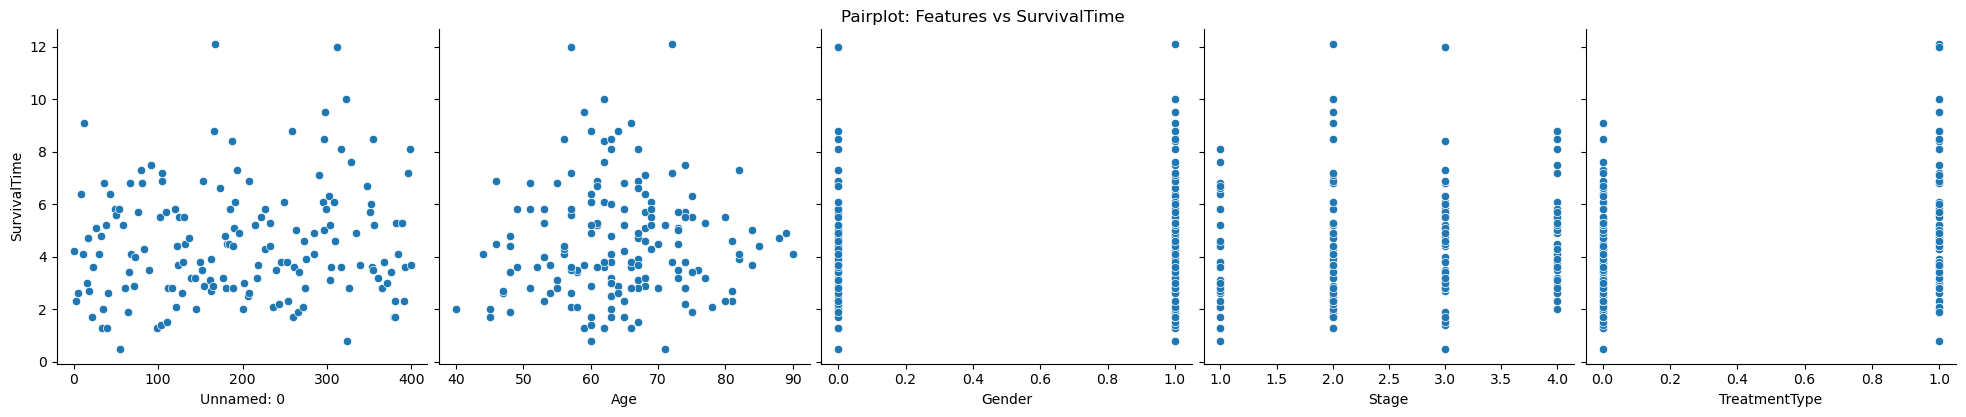

In [153]:
# Select features (exclude SurvivalTime and Censored)
feature_cols = [col for col in df_clean.columns if col not in ['SurvivalTime', 'Censored']]

# Create pairplot
sns.pairplot(df_clean, x_vars=feature_cols, y_vars=['SurvivalTime'], height=4, kind='scatter')
plt.suptitle("Pairplot: Features vs SurvivalTime", y=1.02)
plt.show()

In [156]:
# Features (examples as rows, features as columns)
X = df_clean[feature_cols].values  # numpy array of shape (n_samples, n_features)

# Target variable: SurvivalTime
y = df_clean['SurvivalTime'].values  # numpy array of shape (n_samples,)

# Optional: store the censoring indicator
c = df_clean['Censored'].values  # in case we need it for cMSE later

# Quick check
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First 5 survival times:", y[:5])


Shape of X: (161, 5)
Shape of y: (161,)
First 5 survival times: [4.2 2.3 2.6 6.4 4.1]


### Split Dataset

Our cleaned dataset is relatively small, so a single train/validation split would waste valuable examples and produce high-variance estimates.

5-Fold CV ensures each patient is used multiple times for training and validation, improving data efficiency.

In [160]:
# 5-Fold Cross-Validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline: StandardScaler + LinearRegression
pipeline = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

# Perform cross-validation
# Use negative MSE because cross_val_score expects a score to maximize
cv_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_mean_squared_error')

# Convert to positive MSE
mse_scores = -cv_scores

print("5-Fold Cross-Validation MSE scores:", mse_scores)
print("Mean MSE:", mse_scores.mean())
print("Std MSE:", mse_scores.std())


5-Fold Cross-Validation MSE scores: [4.30774074 3.49395016 2.83025674 7.31366499 4.7090789 ]
Mean MSE: 4.530938304206978
Std MSE: 1.5357591743238828


In [163]:
# TASK 1.1 — cMSE metric (as given in the assignment)

def error_metric(y, y_hat, c):
    import numpy as np
    y = np.asarray(y)
    y_hat = np.asarray(y_hat)
    c = np.asarray(c)
    err = y - y_hat
    err = (1 - c) * (err ** 2) + c * np.maximum(0, err) ** 2
    return np.sum(err) / err.shape[0]

# fallback assuming no censor vector available (treat all as uncensored)def censored_mse(y_true, y_pred, c):
def censored_mse(y_true, y_pred, c):
    err = y_true - y_pred
    # For uncensored data (c=0): squared error
    # For censored data (c=1): squared error only if prediction < observed time
    err = (1 - c) * err**2 + c * np.maximum(0, err)**2
    return np.mean(err)


### Task 1.2 Learn the baseline model

In [166]:
baseline_pipeline = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

# Fit on all uncensored, complete data
baseline_pipeline.fit(X, y)

# Predict on the same data (Task 1 baseline)
y_hat = baseline_pipeline.predict(X)

# Calculate cMSE (equivalent to MSE here, since all uncensored)
c_mse_value = censored_mse(y, y_hat, c)
print("Baseline Linear Regression cMSE (MSE on uncensored data):", c_mse_value)

Baseline Linear Regression cMSE (MSE on uncensored data): 4.0493761374127555


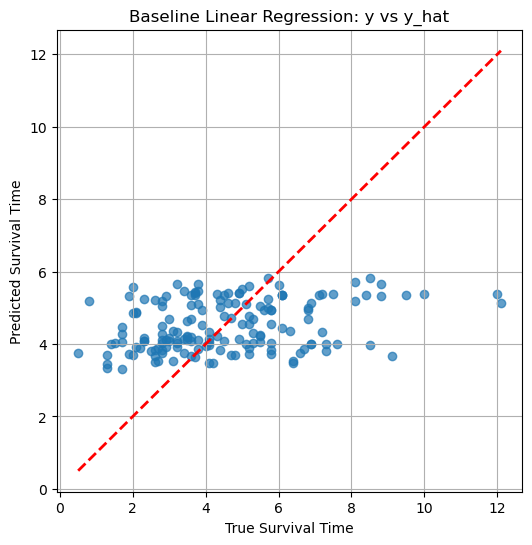

In [167]:
plt.figure(figsize=(6,6))
plt.scatter(y, y_hat, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)  # perfect prediction line
plt.xlabel("True Survival Time")
plt.ylabel("Predicted Survival Time")
plt.title("Baseline Linear Regression: y vs y_hat")
plt.grid(True)
plt.show()

### Kaggle submission

In [ ]:
###

## Task 2 Nonlinear models

### Task 2.1 Development

### Task 2.2 Evaluation

## Task 3 Handling missing data

### Task 3.1 Missing data imputation

### Task 3.2 Train models that do not require imputation

### Task 3.3 Evaluation

## Task 4 Semi-supervised learning for unlabeled data

### Task 4.1 Imputation with labeled and unlabeled data

### Task 4.2 Evaluation

## Task 5 [optional]